## Regime Detection in Financial Markets using Machine Learning (Data Download — CSI 300)
- Author: Abbinav Sankar Kailasam (UCL)
- Supervisors: Dr. Blaz Zlicar (ADIA), Prof. Fabio Caccioli (UCL)

In [17]:
# Standard library, HTTP, and data/finance imports.
from io import StringIO

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from plot_style import set_publication_style, style_axis, format_date_axis, NEUTRAL_COLOURS

set_publication_style()

In [18]:
# Global date range and batch size for the download.
START_DATE  = "2001-01-01"
END_DATE    = "2026-07-15"
BATCH_SIZE  = 50

In [19]:
# Per-index scrape/ticker-map configuration consumed by fetch_constituents.
INDICES = {
    "CSI300": {
        "name": "CSI 300",
        "wiki_url": "https://en.wikipedia.org/wiki/CSI_300_Index",
        "table_match": "segment",
        "symbol_col": "Ticker",
        "suffix_col": "Exchange",
        "suffix_map": {"Shanghai": ".SS", "Shenzhen": ".SZ"},
        "sector_map": {
            "Information Technology"  : "IT",
            "Industrials"             : "IND",
            "Financials"              : "FIN",
            "Materials"               : "MAT",
            "Health Care"             : "HC",
            "Consumer Staples"        : "CST",
            "Consumer Discretionary"  : "CD",
            "Utilities"               : "UTL",
            "Energy"                  : "ENE",
            "Communication"           : "CS",
            "Real Estate"             : "RE",
        },
    },
}

In [20]:
# Build the ticker map for one index from its INDICES config
def fetch_constituents(index_code):
    cfg = INDICES[index_code]

    if "wiki_url" in cfg:
        html = requests.get(cfg["wiki_url"], headers={"User-Agent": "Mozilla/5.0"}).text
        tables = pd.read_html(StringIO(html))

        if "table_match" in cfg:
            df, sector_col = None, None
            for t in tables:
                cols = [str(c) for c in t.columns]
                match = next((c for c in cols if c.lower().startswith(cfg["table_match"])), None)
                if cfg["symbol_col"] in cols and match:
                    df, sector_col = t.dropna(subset=[cfg["symbol_col"]]), match
                    break
            if df is None:
                raise ValueError(f"No table on {cfg['wiki_url']} has {cfg['symbol_col']!r} and a column starting with {cfg['table_match']!r}")
        else:
            df = tables[cfg["table_index"]]
            sector_col = cfg["sector_col"]

        ticker_map = {}
        for _, row in df.iterrows():
            raw_symbol = row[cfg["symbol_col"]]
            if "suffix_col" in cfg:
                _, sep, code = raw_symbol.partition(":")
                if not sep:
                    raise ValueError(f"{cfg['name']}: expected 'PREFIX: CODE' in symbol {raw_symbol!r}")
                epic = code.strip().replace(".", "-")
                exch = row[cfg["suffix_col"]]
                if exch not in cfg["suffix_map"]:
                    raise ValueError(f"{cfg['name']}: exchange {exch!r} not in suffix_map for symbol {raw_symbol!r}")
                suffix = cfg["suffix_map"][exch]
            else:
                epic = raw_symbol.replace(".", "-")
                suffix = cfg.get("suffix", "")
            tk = epic + suffix
            sector_name = row[sector_col]
            if sector_name not in cfg["sector_map"]:
                print(f"WARNING: {cfg['name']} sector {sector_name!r} not in sector_map, falling back to a derived code")
            sector = cfg["sector_map"].get(sector_name, sector_name.replace(" ", "_").upper())
            ticker_map[tk] = f"{sector}_{epic}"

        n_sectors = df[sector_col].nunique()
        print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors")
        return ticker_map

    ticker_map = {}
    for sector, codes in cfg["components"].items():
        for code in codes:
            tk = f"{code}{cfg['suffix']}"
            ticker_map[tk] = f"{sector}_{code}"

    n_sectors = len(cfg["components"])
    print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors "
          f"({cfg['snapshot']} snapshot)")
    return ticker_map

In [21]:
# Batched yfinance download of adjusted close prices for a ticker map, index-agnostic.
def download_prices(ticker_map, start_date, end_date, batch_size=BATCH_SIZE):
    tickers = list(ticker_map.keys())
    batches = [tickers[i:i + batch_size] for i in range(0, len(tickers), batch_size)]

    all_frames = []
    for idx, batch in enumerate(batches, 1):
        print(f"Batch {idx}/{len(batches)}: {batch[0]} … {batch[-1]}", end="  ")
        raw = yf.download(tickers=batch, start=start_date, end=end_date,
                          auto_adjust=True, progress=False, threads=True)

        if isinstance(raw.columns, pd.MultiIndex):
            close = raw["Close"]
        else:
            close = raw[["Close"]].rename(columns={"Close": batch[0]})

        all_frames.append(close)
        print(f"→ {close.shape[1]} tickers, {close.shape[0]} rows")

    df = pd.concat(all_frames, axis=1)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    df.rename(columns=ticker_map, inplace=True)
    return df

In [22]:
# Drop broken adjustments, unadjusted corporate actions, short histories, non-trading days, and prolonged trading halts.
def screen_panel(df):
    bad_price = df.columns[(df <= 0).any()]
    df = df.drop(columns=bad_price)

    r = np.log(df).diff()
    bad_jump = r.columns[(r.abs() > 0.8).any()]
    df = df.drop(columns=bad_jump)

    n_before = df.shape[1]
    df = df.dropna(how="any", axis=1)
    n_incomplete = n_before - df.shape[1]

    r = np.log(df).diff()
    flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
    df = df.loc[~flat]

    HALT_STREAK_DAYS = 63
    r = np.log(df).diff()
    flat_by_stock = r.abs() < 1e-12
    longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
    bad_halt = longest_halt[longest_halt >= HALT_STREAK_DAYS].index
    df = df.drop(columns=bad_halt)

    print(f"non-positive prices : {list(bad_price)}")
    print(f"unadjusted actions  : {list(bad_jump)}")
    print(f"incomplete history  : {n_incomplete} names")
    print(f"non-trading days    : {int(flat.sum())} rows")
    print(f"prolonged halts     : {list(bad_halt)}")
    return df

In [23]:
# Fetch constituents, download prices, clean, and save data/{index_code}_AdjClose_{Raw,Cleaned}.csv.
def download_index(index_code, start_date, end_date, batch_size=BATCH_SIZE):
    ticker_map = fetch_constituents(index_code)
    df_raw = download_prices(ticker_map, start_date, end_date, batch_size)
    df_raw.to_csv(f"data/{index_code}_AdjClose_Raw.csv", index=True)

    df_clean = screen_panel(df_raw)
    print(df_clean.shape)
    df_clean.to_csv(f"data/{index_code}_AdjClose_Cleaned.csv", index=True)
    return df_clean

In [24]:
# Download and clean the CSI 300 panel.
df_csi300 = download_index("CSI300", START_DATE, END_DATE)

Found 300 CSI 300 tickers across 11 sectors
Batch 1/6: 600519.SS … 600690.SS  → 50 tickers, 6291 rows
Batch 2/6: 601728.SS … 600938.SS  

$601989.SS: possibly delisted; no timezone found
$600837.SS: possibly delisted; no timezone found

2 Failed downloads:
['601989.SS', '600837.SS']: possibly delisted; no timezone found


→ 50 tickers, 6291 rows
Batch 3/6: 600999.SS … 300896.SZ  → 50 tickers, 6291 rows
Batch 4/6: 688256.SS … 000983.SZ  → 50 tickers, 6291 rows
Batch 5/6: 601881.SS … 300413.SZ  → 50 tickers, 6291 rows
Batch 6/6: 601615.SS … 001289.SZ  → 50 tickers, 6291 rows
non-positive prices : []
unadjusted actions  : ['IT_002230', 'MAT_000792', 'FIN_000776', 'CST_000895', 'IND_600372', 'RE_600515', 'IT_300628', 'IND_600018']
incomplete history  : 223 names
non-trading days    : 104 rows
prolonged halts     : ['CD_000651', 'CD_600690', 'RE_000002', 'CD_000625', 'MAT_600019', 'IND_600089', 'IND_600150', 'FIN_000166', 'HC_000538', 'CST_000596', 'IT_000938', 'IND_600760', 'UTL_600886', 'IND_600893', 'MAT_601600', 'MAT_000301', 'IND_000786', 'HC_000963', 'RE_001979', 'IND_600115', 'IT_600745', 'MAT_000408', 'CST_000876', 'HC_000999', 'IND_600233', 'HC_601607', 'FIN_000617', 'MAT_000708', 'FIN_600061', 'RE_600606', 'IT_600732', 'UTL_600803', 'IND_600875']
(6187, 36)


In [25]:
df_raw = pd.read_csv("data/CSI300_AdjClose_Raw.csv", index_col="Date", parse_dates=True)
df_raw.head()

,FIN_000001,IT_000063,CD_000333,IND_000338,CST_000568,CD_000651,IT_000725,CST_000858,IT_002230,IND_002352,...,MAT_603659,CD_603833,IND_603899,IND_605117,CST_605499,MAT_688065,IND_688187,IT_688223,HC_688363,IT_688561
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,2.840168,3.783486,NaN,NaN,2.028443,0.296753,NaN,3.439870,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-02,2.846036,3.861998,NaN,NaN,2.079195,0.302912,NaN,3.466838,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-03,2.824520,3.998152,NaN,NaN,2.128310,0.308108,NaN,3.497287,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-04,2.806916,3.915665,NaN,NaN,2.118487,0.307915,NaN,3.495548,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01-05,2.777575,3.841128,NaN,NaN,2.195434,0.313689,NaN,3.462488,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df_clean = pd.read_csv("data/CSI300_AdjClose_Cleaned.csv", index_col="Date", parse_dates=True)
df_clean.head()

,FIN_000001,IT_000063,CST_000568,CST_000858,FIN_600016,HC_600276,CST_600809,CST_600887,FIN_600000,CD_600104,...,IT_600845,IT_000733,MAT_600176,IT_600183,MAT_600219,RE_000069,IND_000800,MAT_000877,CST_600132,CD_600754
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-01,2.840168,3.783486,2.028443,3.439870,0.459702,0.571114,2.446670,1.068806,1.200860,1.688852,...,2.487898,11.235557,0.658555,2.760694,1.897317,0.828243,4.472330,4.409726,3.257196,8.031075
2001-01-02,2.846036,3.861998,2.079195,3.466838,0.464240,0.587025,2.483853,1.101442,1.210698,1.698487,...,2.482057,11.276914,0.661232,2.763950,1.951784,0.855187,4.506893,4.409726,3.223654,7.896476
2001-01-03,2.824520,3.998152,2.128310,3.497287,0.461838,0.584373,2.503684,1.097363,1.204911,1.713627,...,2.490233,11.559527,0.727623,2.691214,1.950650,0.847642,4.486155,4.444649,3.344775,8.357959
2001-01-04,2.806916,3.915665,2.118487,3.495548,0.458100,0.585131,2.464022,1.109601,1.195073,1.727392,...,2.522939,11.504386,0.718521,2.724869,1.915472,0.868119,4.569105,4.466708,3.341049,8.351549
2001-01-05,2.777575,3.841128,2.195434,3.462488,0.451693,0.596307,2.516079,1.138157,1.179447,1.775566,...,2.521770,11.359632,0.736724,2.758523,1.980153,0.871352,4.658966,4.304951,3.391360,8.351549


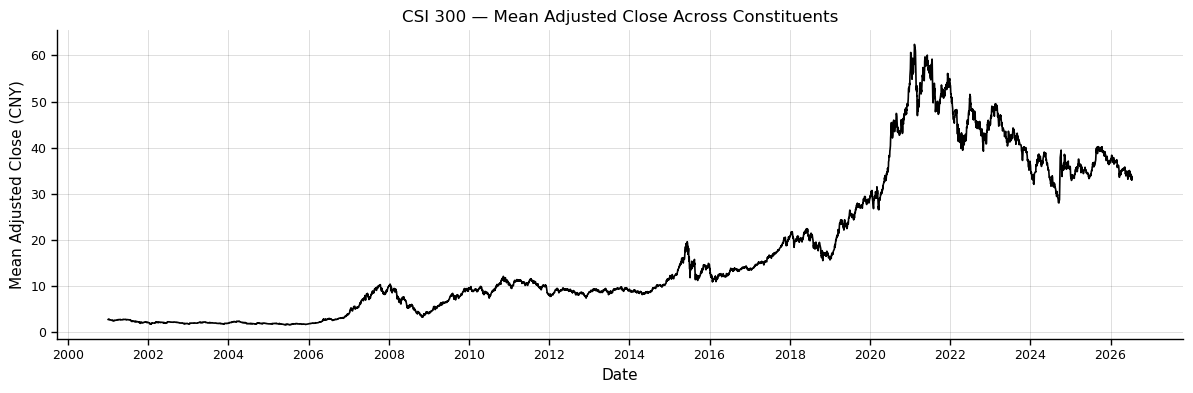

In [27]:
# Mean adjusted close across CSI 300 constituents, EPJ-styled.
mean_price = df_clean.mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mean_price.index, mean_price.values, color=NEUTRAL_COLOURS["primary"], linewidth=1.2)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("CSI 300 — Mean Adjusted Close Across Constituents")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Adjusted Close (CNY)")
fig.tight_layout()
plt.show()

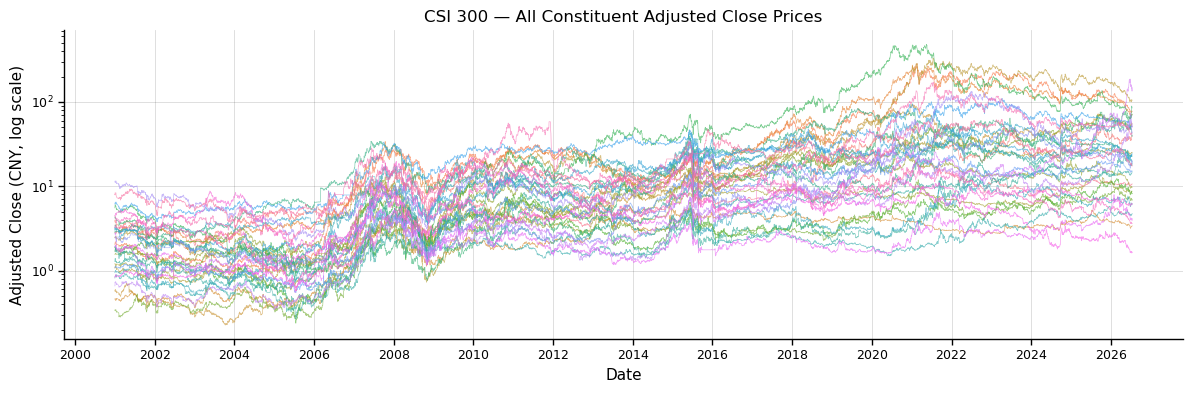

In [28]:
# All individual constituent prices overlaid, EPJ-styled (log scale: raw price levels span orders of magnitude across constituents), one colour per stock.
colours = sns.color_palette("husl", len(df_clean.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(df_clean.index, df_clean.values, alpha=0.6, linewidth=0.5)
ax.set_yscale("log")
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("CSI 300 — All Constituent Adjusted Close Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close (CNY, log scale)")
fig.tight_layout()
plt.show()

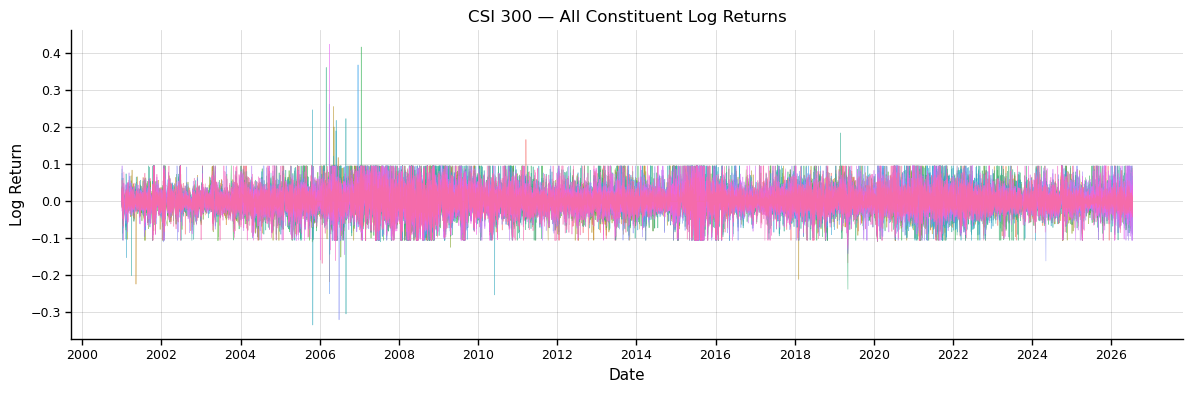

In [29]:
# All individual constituent log returns overlaid, EPJ-styled, one colour per stock.
log_returns = np.log(df_clean).diff()
colours = sns.color_palette("husl", len(log_returns.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(log_returns.index, log_returns.values, alpha=0.6, linewidth=0.5)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("CSI 300 — All Constituent Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
fig.tight_layout()
plt.show()

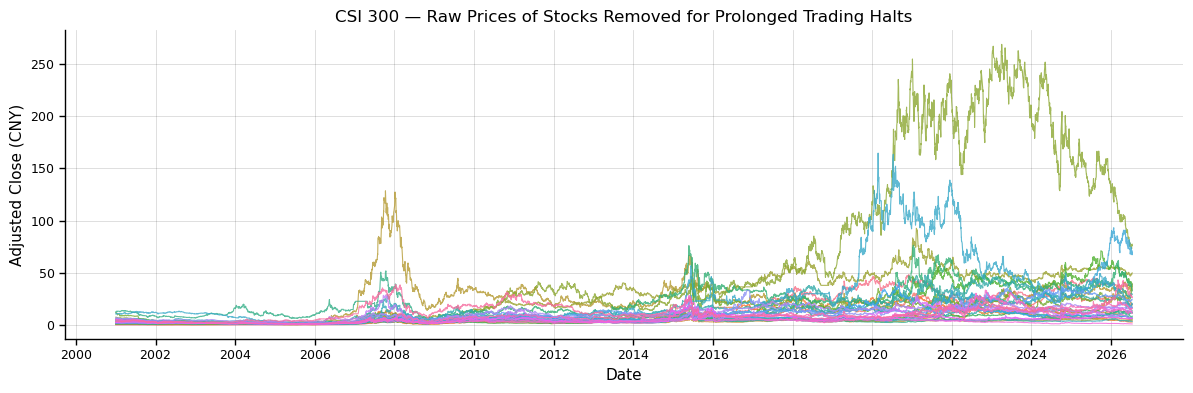

In [30]:
# Raw price series of stocks removed by the prolonged trading halt screen.
df = df_raw.drop(columns=df_raw.columns[(df_raw <= 0).any()])
r = np.log(df).diff()
df = df.drop(columns=r.columns[(r.abs() > 0.8).any()])
df = df.dropna(how="any", axis=1)
r = np.log(df).diff()
flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
df = df.loc[~flat]

HALT_STREAK_DAYS = 63
r = np.log(df).diff()
flat_by_stock = r.abs() < 1e-12
longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
halted_stocks = longest_halt[longest_halt >= HALT_STREAK_DAYS].index

if len(halted_stocks) > 0:
    colours = sns.color_palette("husl", len(halted_stocks))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_prop_cycle(color=colours)
    for stock in halted_stocks:
        ax.plot(df_raw.index, df_raw[stock], alpha=0.8, linewidth=0.8, label=stock)
    style_axis(ax, grid=True)
    format_date_axis(ax, interval_years=2)
    ax.set_title("CSI 300 — Raw Prices of Stocks Removed for Prolonged Trading Halts")
    ax.set_xlabel("Date")
    ax.set_ylabel("Adjusted Close (CNY)")
    fig.tight_layout()
    plt.show()
else:
    print("No stocks removed for prolonged trading halts.")

In [31]:
longest_halt.sort_values(ascending=False).head(10)

IND_600893    364
IT_600732     295
IT_600745     290
FIN_000166    175
RE_600606     170
RE_000002     130
MAT_000408    129
CST_000876    129
IND_600150    117
HC_000538     111
dtype: int64